## Step 2 — Participation in Ancillary Service Markets

In this step, the participation of a price-taking stochastic flexible load in the DK2 FCR-D Up market is analysed. The flexible load can provide upward frequency containment reserve by quickly reducing its electricity consumption.

A single bidding hour is considered with minute-level resolution. Therefore, each load profile consists of 60 consumption values, one for each minute of the hour.

## Data Generation for Future Stochastic Load

A total of 300 stochastic load profiles are generated. Each load profile satisfies the following conditions:

- Consumption remains between 220 kW and 600 kW.
- Minute-to-minute changes do not exceed 35 kW.

The 300 profiles are split into:

- 100 in-sample profiles, used for the reserve bidding decision.
- 200 out-of-sample profiles, used later for verification.

For FCR-D Up, the flexible load provides reserve by reducing consumption. Therefore, the available upward flexibility is equal to the current consumption level:

$$
F^{\uparrow}_{s,m} = L_{s,m}
$$

where \(L_{s,m}\) is the consumption of profile \(s\) in minute \(m\).

## Task 2.1 — In-Sample Decision Making under the P90 Requirement

The objective is to determine the maximum FCR-D Up reserve capacity bid using the 100 in-sample load profiles.

The decision variable is:

$$
c^{\uparrow}
$$

where \(c^{\uparrow}\) is the FCR-D Up reserve bid in kW.

The P90 requirement means that the offered reserve capacity must be available with at least 90% probability. Equivalently, the probability of reserve shortfall, or overbidding, must be at most 10%.

This task is solved using two methods:

1. ALSO-X / sample-based MILP formulation.
2. CVaR approximation.


## ALSO-X / Sample-Based MILP Formulation

The ALSO-X formulation directly limits the number of sample-minute violations.

A binary variable is introduced:

$$
y_{s,m} =
\begin{cases}
1, & \text{if the reserve bid exceeds available flexibility} \\
0, & \text{otherwise}
\end{cases}
$$

The availability constraint is written as:

$$
c^{\uparrow} - F^{\uparrow}_{s,m} \leq M y_{s,m}
\qquad \forall s,m
$$

where \(M\) is a sufficiently large constant.

If \(y_{s,m}=0\), the reserve bid must be feasible in that minute and scenario. If \(y_{s,m}=1\), a violation is allowed.

The P90 requirement is enforced by limiting the total number of violations:

$$
\sum_s \sum_m y_{s,m}
\leq
\epsilon N M_t
$$

where:

$$
\epsilon = 0.10
$$

\(N\) is the number of in-sample profiles, and \(M_t=60\) is the number of minutes in the bidding hour.

The optimization problem is:

$$
\max c^{\uparrow}
$$

subject to the availability constraints and the violation budget.

In [28]:
# ============================================
# TASK 2.1 — ALSO-X / sample-based MILP
# FCR-D Up reserve bid under P90 requirement
# ============================================

import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

load_in = np.load("../data/load_in.npy")
load_out = np.load("../data/load_out.npy")
F_up_in = np.load("../data/F_up_in.npy")
F_up_out = np.load("../data/F_up_out.npy")

N_in, M = F_up_in.shape
N_out, _ = F_up_out.shape

epsilon = 0.10          # P90 requirement -> max 10% violation
M_big = 10000           # Big-M
q = int(epsilon * N_in * M)

model_alsox = gp.Model("Task_2_1_ALSOX_FCRD_Up")
model_alsox.setParam("OutputFlag", 0)

# Decision variable: reserve capacity bid [kW]
c_up = model_alsox.addVar(lb=0, name="c_up")

# Binary violation variable
y = model_alsox.addVars(N_in, M, vtype=GRB.BINARY, name="y")

# If c_up > available flexibility, violation is allowed through y
for s in range(N_in):
    for m in range(M):
        model_alsox.addConstr(
            c_up - F_up_in[s, m] <= M_big * y[s, m],
            name=f"availability_{s}_{m}"
        )

# Violation budget: at most 10% of all sample-minute cases
model_alsox.addConstr(
    gp.quicksum(y[s, m] for s in range(N_in) for m in range(M)) <= q,
    name="P90_violation_budget"
)

# Objective: maximize reserve bid
model_alsox.setObjective(c_up, GRB.MAXIMIZE)

model_alsox.optimize()

if model_alsox.status == GRB.OPTIMAL:
    c_up_alsox = c_up.X
    print("========== ALSO-X / MILP RESULT ==========")
    print(f"Optimal FCR-D Up reserve bid: {c_up_alsox:.2f} kW")
    print(f"Allowed violations: {q} out of {N_in*M}")
    print(f"In-sample violation count: {sum(y[s,m].X for s in range(N_in) for m in range(M)):.0f}")
else:
    print("ALSO-X model not optimal. Status:", model_alsox.status)

========== ALSO-X / MILP RESULT ==========
Optimal FCR-D Up reserve bid: 242.21 kW
Allowed violations: 600 out of 6000
In-sample violation count: 600


## CVaR Approximation

The CVaR formulation approximates the P90 requirement by controlling the magnitude of reserve shortfalls.

The reserve shortfall is defined as:

$$
\xi_{s,m} \geq c^{\uparrow} - F^{\uparrow}_{s,m}
$$

$$
\xi_{s,m} \geq 0
$$

Instead of only counting how often the reserve bid is infeasible, CVaR also accounts for how large the infeasibility is.

The CVaR formulation is linear and avoids binary variables. However, because it controls the size of shortfalls, it is usually more conservative than ALSO-X.

In [36]:
# ============================================
# TASK 2.1 — CVaR approximation
# FCR-D Up reserve bid under P90 requirement
# ============================================

model_cvar = gp.Model("Task_2_1_CVaR_FCRD_Up")
model_cvar.setParam("OutputFlag", 0)

# Decision variable: reserve capacity bid [kW]
c_up_cvar = model_cvar.addVar(lb=0, ub=GRB.INFINITY, name="c_up")

# CVaR variables
beta = model_cvar.addVar(ub=0, lb=-GRB.INFINITY, name="beta")          # VaR-like threshold
shortfall = model_cvar.addVars(N_in, M, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="shortfall") # N_in, M shortfall variables can be negative (overperformance) or positive (underperformance)
# Shortfall constraints
for s in range(N_in):
    for m in range(M):
        model_cvar.addConstr(
            c_up_cvar - F_up_in[s, m] <= shortfall[s, m],
            name=f"shortfall_{s}_{m}"
        )

        model_cvar.addConstr(
            beta <= shortfall[s, m],
            name=f"beta_bound_{s}_{m}"
        )

# CVaR conservative approximation
model_cvar.addConstr(
    gp.quicksum(shortfall[s, m] for s in range(N_in) for m in range(M)) / (N_in * M)
    <= (1 - epsilon) * beta,
    name="CVaR_constraint"
)

# Objective: maximize reserve bid
model_cvar.setObjective(c_up_cvar, GRB.MAXIMIZE)

model_cvar.optimize()

if model_cvar.status == GRB.OPTIMAL:
    c_up_cvar_val = c_up_cvar.X
    print("\n========== CVaR RESULT ==========")
    print(f"Optimal FCR-D Up reserve bid: {c_up_cvar_val:.2f} kW")
    print(f"beta value: {beta.X:.2f}")
else:
    print("CVaR model not optimal. Status:", model_cvar.status)


========== CVaR RESULT ==========
Optimal FCR-D Up reserve bid: 226.26 kW
beta value: -15.77



========== EXTENDED CVaR ANALYSIS ==========
VaR (beta): -15.7743
Number of violations: 357 / 6000
Violation rate: 5.95%
Average violation (all): 0.3318 kW
Average violation (given violation): 5.5770 kW
Max violation: 6.2615 kW


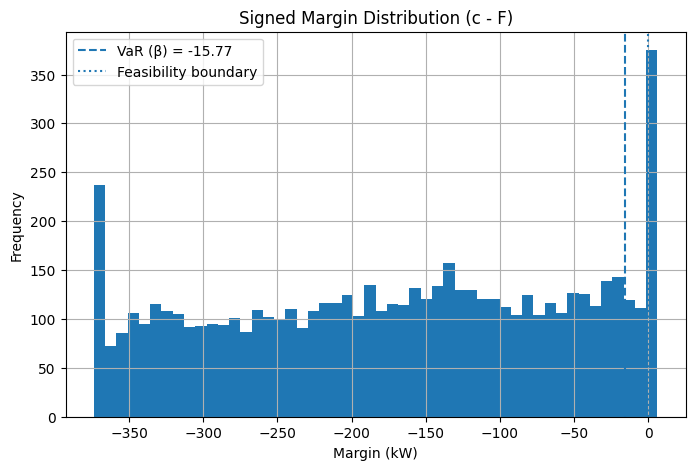

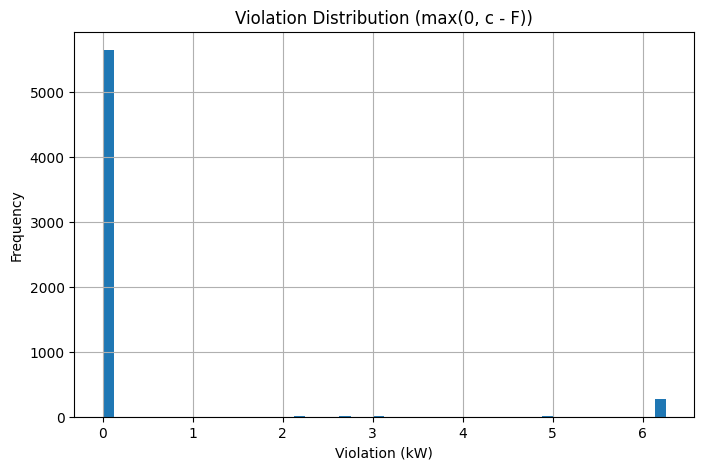


Empirical (violation-based) metrics:
VaR (90%) on violations: 0.0000 kW
CVaR (90%) on violations: 0.3318 kW


In [37]:
# ============================================
# EXTENDED RESULTS — CVaR ANALYSIS
# ============================================

import numpy as np
import matplotlib.pyplot as plt

if model_cvar.status == GRB.OPTIMAL:

    c_val = c_up_cvar.X
    beta_val = beta.X

    print("\n========== EXTENDED CVaR ANALYSIS ==========")

    # -----------------------------
    # 1. Signed margin (model view)
    # -----------------------------
    margin = c_val - F_up_in
    margin_flat = margin.flatten()

    # -----------------------------
    # 2. TRUE violations (engineering view)
    # -----------------------------
    violations = np.maximum(0, margin)
    violations_flat = violations.flatten()

    # -----------------------------
    # 3. Metrics
    # -----------------------------
    N_total = N_in * M

    num_violations = np.sum(violations_flat > 0)
    violation_rate = num_violations / N_total

    avg_violation = violations_flat.mean()
    max_violation = violations_flat.max()

    # conditional average (only when violation happens)
    if num_violations > 0:
        avg_violation_cond = violations_flat[violations_flat > 0].mean()
    else:
        avg_violation_cond = 0.0

    print(f"VaR (beta): {beta_val:.4f}")
    print(f"Number of violations: {num_violations} / {N_total}")
    print(f"Violation rate: {violation_rate*100:.2f}%")
    print(f"Average violation (all): {avg_violation:.4f} kW")
    print(f"Average violation (given violation): {avg_violation_cond:.4f} kW")
    print(f"Max violation: {max_violation:.4f} kW")

    # -----------------------------
    # 4. PLOT — signed margin
    # -----------------------------
    plt.figure(figsize=(8,5))
    plt.hist(margin_flat, bins=50)
    plt.axvline(beta_val, linestyle="--", label=f"VaR (β) = {beta_val:.2f}")
    plt.axvline(0, linestyle=":", label="Feasibility boundary")
    plt.title("Signed Margin Distribution (c - F)")
    plt.xlabel("Margin (kW)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()

    # -----------------------------
    # 5. PLOT — TRUE violations
    # -----------------------------
    plt.figure(figsize=(8,5))
    plt.hist(violations_flat, bins=50)
    plt.title("Violation Distribution (max(0, c - F))")
    plt.xlabel("Violation (kW)")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

    # -----------------------------
    # 6. OPTIONAL — empirical VaR/CVaR on violations
    # -----------------------------
    alpha = 0.10
    threshold = np.quantile(violations_flat, 1 - alpha)

    tail = violations_flat[violations_flat >= threshold]

    if len(tail) > 0:
        CVaR_emp = tail.mean()
    else:
        CVaR_emp = 0.0

    print("\nEmpirical (violation-based) metrics:")
    print(f"VaR (90%) on violations: {threshold:.4f} kW")
    print(f"CVaR (90%) on violations: {CVaR_emp:.4f} kW")

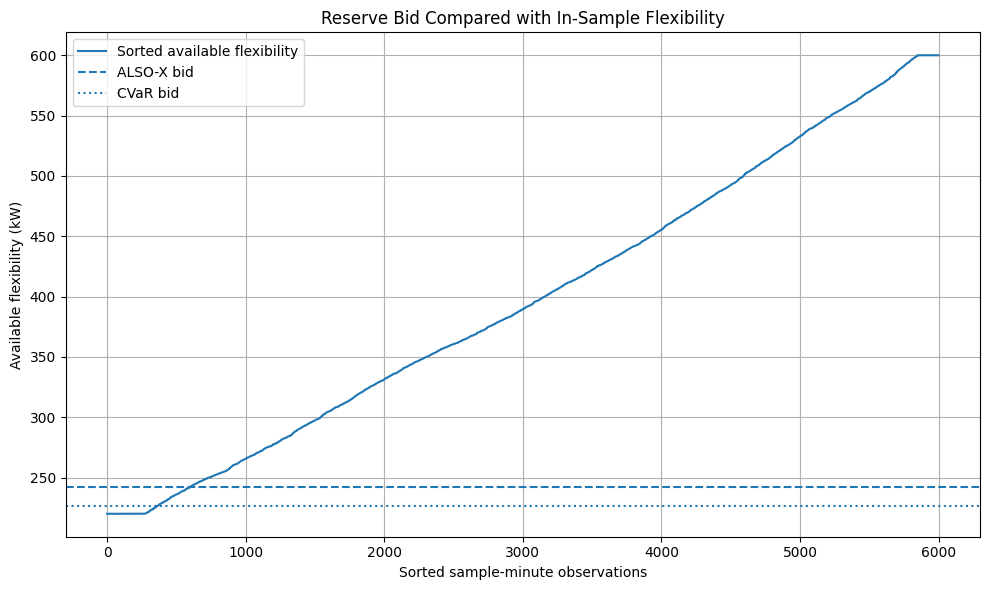

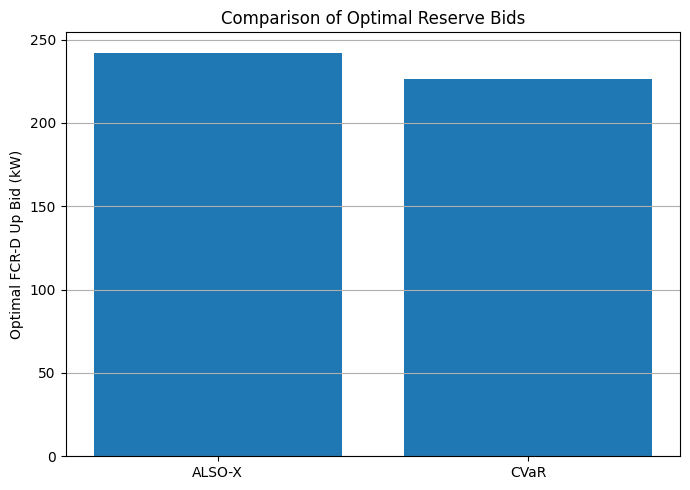

In [3]:
# ============================================
# Task 2.1 Summary
# ============================================

task_2_1_results = pd.DataFrame({
    "Method": ["ALSO-X / MILP", "CVaR approximation"],
    "Optimal reserve bid [kW]": [c_up_alsox, c_up_cvar_val]
})

task_2_1_results



all_flex = F_up_in.flatten()
sorted_flex = np.sort(all_flex)

plt.figure(figsize=(10,6))

plt.plot(sorted_flex, label="Sorted available flexibility")
plt.axhline(c_up_alsox, linestyle="--", label="ALSO-X bid")
plt.axhline(c_up_cvar_val, linestyle=":", label="CVaR bid")

plt.xlabel("Sorted sample-minute observations")
plt.ylabel("Available flexibility (kW)")
plt.title("Reserve Bid Compared with In-Sample Flexibility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))

plt.bar(
    ["ALSO-X", "CVaR"],
    [c_up_alsox, c_up_cvar_val]
)

plt.ylabel("Optimal FCR-D Up Bid (kW)")
plt.title("Comparison of Optimal Reserve Bids")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Task 2.2 — Verification of the P90 Requirement (Out-of-Sample)

In this task, the robustness of the reserve bids obtained from the in-sample optimization is evaluated using **200 out-of-sample load profiles**. No optimization is performed; instead, the performance of each solution is assessed by comparing the reserve bid with the realized flexibility at each minute.

For a given reserve bid $c^{\uparrow}$, a violation occurs whenever the available flexibility is insufficient to meet the bid:

$$
\text{violation}_{s,m} = \max\left(0,\, c^{\uparrow} - F^{\uparrow}_{s,m}\right)
$$

where $F^{\uparrow}_{s,m}$ denotes the available upward flexibility for scenario $s$ at minute $m$.

The P90 requirement is satisfied if the probability of violation does not exceed 10%, i.e.:

$$
\frac{\#\{(s,m) : c^{\uparrow} > F^{\uparrow}_{s,m}\}}{|\Omega|\cdot |\mathcal{M}|} \le 0.10
$$

To assess the performance of each method, the following metrics are computed:

- Violation rate: fraction of sample-minute pairs with infeasibility  
- Average violation: mean magnitude of reserve shortfall  
- Maximum violation: worst observed infeasibility  
- Conditional average violation: average shortfall given that a violation occurs  

This analysis provides insight into both the frequency and the severity of infeasibilities.

Typically, the ALSO-X solution is expected to satisfy the P90 requirement by construction, resulting in a violation rate close to 10%. In contrast, the CVaR-based formulation used in this assignment is more conservative, often leading to zero violations in the out-of-sample evaluation.

---




In [4]:
# ============================================
# TASK 2.2 — OUT-OF-SAMPLE VERIFICATION
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data
F_up_out = np.load("../data/F_up_out.npy")
N_out, M = F_up_out.shape


# --------------------------------------------
# Evaluation function
# --------------------------------------------
def evaluate_p90(c_up, name, store_dict=None):
    
    # Compute violations (TRUE magnitude)
    violations = np.maximum(0, c_up - F_up_out)
    
    # Flatten for plotting
    violations_flat = violations.flatten()
    
    # Metrics
    violation_rate = np.mean(violations > 0)
    avg_violation = violations.mean()
    max_violation = violations.max()
    
    if np.sum(violations > 0) > 0:
        avg_violation_cond = violations[violations > 0].mean()
    else:
        avg_violation_cond = 0.0

    print(f"\n========== {name} ==========")
    print(f"Bid: {c_up:.2f} kW")
    print(f"Violation rate: {violation_rate*100:.2f}%")
    print(f"Average violation: {avg_violation:.4f} kW")
    print(f"Max violation: {max_violation:.4f} kW")
    print(f"Avg violation (given violation): {avg_violation_cond:.4f} kW")

    if violation_rate <= 0.10:
        print("✅ P90 requirement SATISFIED")
    else:
        print("❌ P90 requirement VIOLATED")

    # Store results if dictionary provided
    if store_dict is not None:
        store_dict[name] = {
            "bid": c_up,
            "violations": violations,
            "violations_flat": violations_flat,
            "violation_rate": violation_rate,
            "avg_violation": avg_violation,
            "max_violation": max_violation
        }

    return violations, violations_flat


# --------------------------------------------
# Run evaluation for both methods
# --------------------------------------------
results_out = {}

evaluate_p90(c_up_alsox, "ALSO-X", results_out)
evaluate_p90(c_up_cvar_val, "CVaR", results_out)





========== ALSO-X ==========
Bid: 242.21 kW
Violation rate: 7.11%
Average violation: 1.1004 kW
Max violation: 22.2086 kW
Avg violation (given violation): 15.4807 kW
✅ P90 requirement SATISFIED

========== CVaR ==========
Bid: 226.26 kW
Violation rate: 3.98%
Average violation: 0.2156 kW
Max violation: 6.2615 kW
Avg violation (given violation): 5.4246 kW
✅ P90 requirement SATISFIED


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(200, 60)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(12000,)))

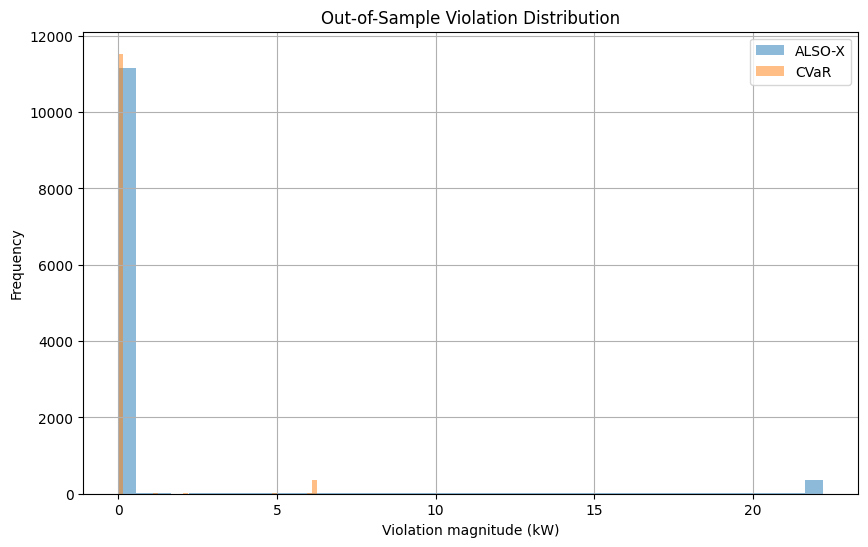

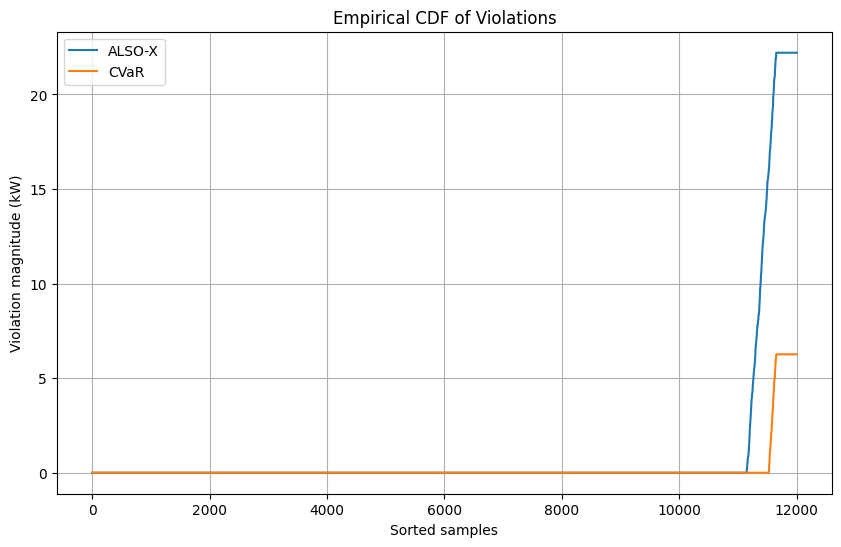

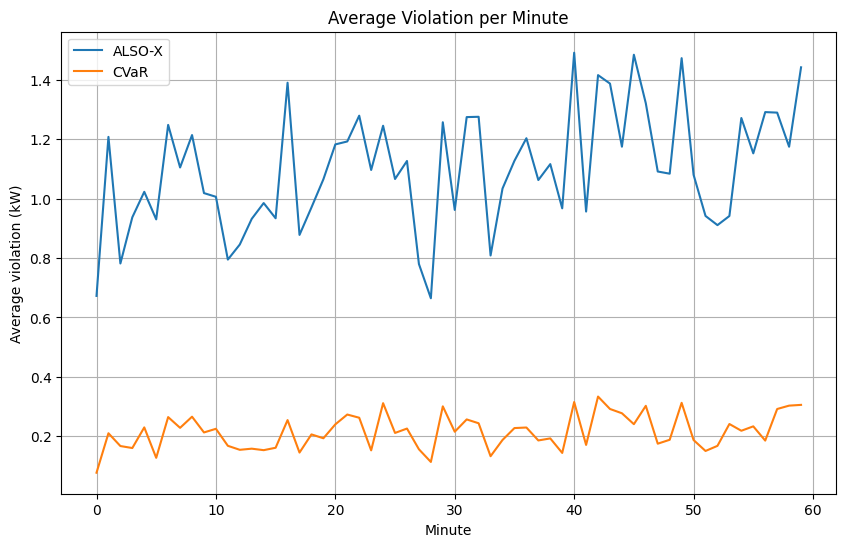


========== SUMMARY ==========
   Method    Bid (kW)  Violation rate (%)  Avg violation (kW)  \
0  ALSO-X  242.208554            7.108333            1.100420   
1    CVaR  226.261461            3.975000            0.215629   

   Max violation (kW)  
0           22.208554  
1            6.261461  


In [5]:
# ============================================
# PLOTS
# ============================================

# 1. Histogram comparison
plt.figure(figsize=(10,6))

for name, data in results_out.items():
    plt.hist(data["violations_flat"], bins=40, alpha=0.5, label=name)

plt.xlabel("Violation magnitude (kW)")
plt.ylabel("Frequency")
plt.title("Out-of-Sample Violation Distribution")
plt.legend()
plt.grid()
plt.show()


# 2. Empirical CDF (VERY strong plot)
plt.figure(figsize=(10,6))

for name, data in results_out.items():
    sorted_v = np.sort(data["violations_flat"])
    plt.plot(sorted_v, label=name)

plt.xlabel("Sorted samples")
plt.ylabel("Violation magnitude (kW)")
plt.title("Empirical CDF of Violations")
plt.legend()
plt.grid()
plt.show()


# 3. Average violation per minute
plt.figure(figsize=(10,6))

for name, data in results_out.items():
    avg_per_minute = data["violations"].mean(axis=0)
    plt.plot(avg_per_minute, label=name)

plt.xlabel("Minute")
plt.ylabel("Average violation (kW)")
plt.title("Average Violation per Minute")
plt.legend()
plt.grid()
plt.show()


# ============================================
# SUMMARY TABLE
# ============================================

summary = []

for name, data in results_out.items():
    summary.append({
        "Method": name,
        "Bid (kW)": data["bid"],
        "Violation rate (%)": data["violation_rate"] * 100,
        "Avg violation (kW)": data["avg_violation"],
        "Max violation (kW)": data["max_violation"]
    })

df_summary = pd.DataFrame(summary)

print("\n========== SUMMARY ==========")
print(df_summary)



## Task 2.3 — Energinet Perspective: Sensitivity to the P90 Requirement

In this task, the impact of varying the reliability requirement is analyzed from the perspective of the system operator. The P90 requirement is generalized by considering different violation thresholds:

$$
\epsilon \in [0, 0.2]
$$

corresponding to reliability levels between 100% and 80%.

For each value of $\epsilon$, the ALSO-X optimization problem is solved to obtain the optimal reserve bid:

$$
c^{\uparrow}(\epsilon)
$$

The resulting bids are then evaluated using out-of-sample data to compute the associated violation rate and magnitude.

This analysis reveals a fundamental trade-off between:

- Reliability (low probability of violations)
- Reserve provision (higher offered capacity)

As the reliability requirement becomes more stringent (i.e., $\epsilon \to 0$), the reserve bid decreases, since the system must remain feasible under a larger fraction of scenarios. Conversely, relaxing the reliability requirement (higher $\epsilon$) allows for larger bids, at the cost of increased violation frequency and magnitude.

This trade-off highlights the key decision faced by the system operator:

- A high reliability requirement ensures secure operation but limits the amount of reserve capacity available  
- A lower reliability requirement increases reserve provision but introduces higher risk of infeasibility  

The results illustrate that even small relaxations of the reliability requirement can significantly increase the offered reserve, while also leading to a non-negligible increase in both the probability and magnitude of violations.

---

## Key Insight

The sensitivity analysis demonstrates that the choice of the reliability threshold $\epsilon$ plays a crucial role in balancing system security and market efficiency. The ALSO-X formulation provides a transparent way to quantify this trade-off and can support system operators such as Energinet in setting appropriate reliability standards.

In [21]:
# ============================================
# TASK 2.3 — P-SENSITIVITY ANALYSIS FOR ALSO-X
# ============================================

epsilons = np.linspace(0, 0.2, 9)   # 0%, 2.5%, ..., 20%

results_sensitivity = []

def solve_alsox(epsilon):

    model = gp.Model()
    model.setParam("OutputFlag", 0)

    c_up = model.addVar(lb=0)
    y = model.addVars(N_in, M, vtype=GRB.BINARY)

    M_big = 500
    q = int(epsilon * N_in * M)

    for s in range(N_in):
        for m in range(M):
            model.addConstr(c_up - F_up_in[s,m] <= M_big * y[s,m])

    model.addConstr(
        gp.quicksum(y[s,m] for s in range(N_in) for m in range(M)) <= q
    )

    model.setObjective(c_up, GRB.MAXIMIZE)
    model.optimize()

    return c_up.X

def evaluate_out(c_up):
    violations = np.maximum(0, c_up - F_up_out)

    return {
        "violation_rate": np.mean(violations > 0),
        "avg_violation": violations.mean(),
        "max_violation": violations.max()
    }

In [22]:
for eps in epsilons:

    c_val = solve_alsox(eps)
    metrics = evaluate_out(c_val)

    results_sensitivity.append({
        "epsilon": eps,
        "reliability": 1 - eps,
        "bid": c_val,
        "violation_rate": metrics["violation_rate"],
        "avg_violation": metrics["avg_violation"]
    })

df_sens = pd.DataFrame(results_sensitivity)
print(df_sens)

   epsilon  reliability         bid  violation_rate  avg_violation
0    0.000        1.000  220.000000        0.000000       0.000000
1    0.025        0.975  220.000000        0.000000       0.000000
2    0.050        0.950  221.657172        0.032250       0.050750
3    0.075        0.925  232.655361        0.052083       0.512349
4    0.100        0.900  242.208554        0.071083       1.100420
5    0.125        0.875  250.691450        0.090833       1.788800
6    0.150        0.850  259.249737        0.113000       2.665604
7    0.175        0.825  268.478210        0.134500       3.807974
8    0.200        0.800  277.682231        0.155167       5.145842


In [23]:
def solve_cvar(epsilon):

    model = gp.Model()
    model.setParam("OutputFlag", 0)

    c_up = model.addVar(lb=0, ub=GRB.INFINITY)
    beta = model.addVar(ub=0, lb=-GRB.INFINITY)
    zeta = model.addVars(N_in, M, lb=-GRB.INFINITY, ub=GRB.INFINITY)

    # Constraints
    for s in range(N_in):
        for m in range(M):
            model.addConstr(c_up - F_up_in[s,m] <= zeta[s,m])
            model.addConstr(beta <= zeta[s,m])

    model.addConstr(
        gp.quicksum(zeta[s,m] for s in range(N_in) for m in range(M)) / (N_in*M)
        <= (1 - epsilon) * beta
    )

    model.setObjective(c_up, GRB.MAXIMIZE)
    model.optimize()

    return c_up.X

In [38]:
results_sensitivity_cvar = []

for eps in epsilons:

    c_val = solve_cvar(eps)
    metrics = evaluate_out(c_val)

    results_sensitivity_cvar.append({
        "epsilon": eps,
        "reliability": 1 - eps,
        "bid": c_val,
        "violation_rate": metrics["violation_rate"],
        "avg_violation": metrics["avg_violation"]
    })

df_sens_cvar = pd.DataFrame(results_sensitivity_cvar)
print(df_sens_cvar)

   epsilon  reliability         bid  violation_rate  avg_violation
0    0.000        1.000  220.000000        0.000000       0.000000
1    0.025        0.975  220.000000        0.000000       0.000000
2    0.050        0.950  220.078814        0.029083       0.002292
3    0.075        0.925  222.493284        0.033583       0.078209
4    0.100        0.900  226.261461        0.039750       0.215629
5    0.125        0.875  230.375481        0.048667       0.397793
6    0.150        0.850  234.364823        0.055500       0.603500
7    0.175        0.825  238.606592        0.064583       0.857767
8    0.200        0.800  242.904325        0.072833       1.150580


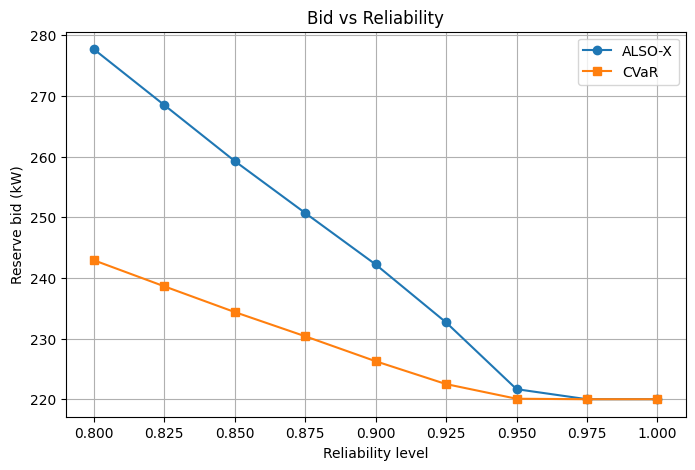

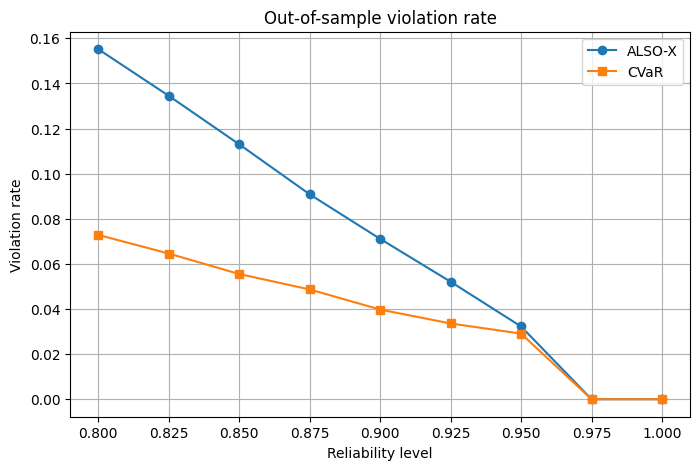

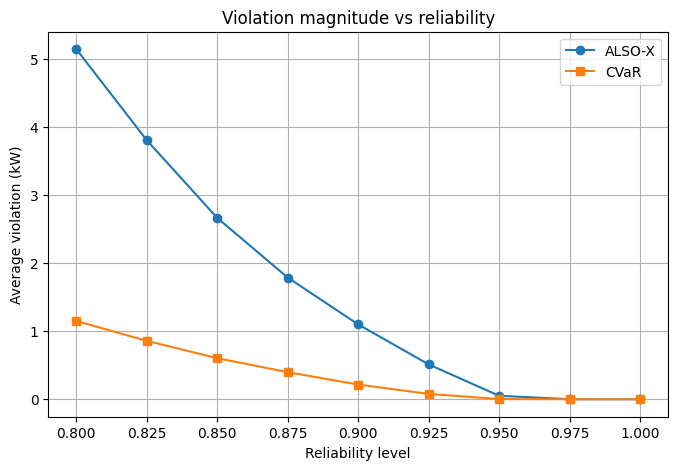

In [25]:
# Plotting sensitivity results

plt.figure(figsize=(8,5))

plt.plot(df_sens["reliability"], df_sens["bid"], marker='o', label="ALSO-X")
plt.plot(df_sens_cvar["reliability"], df_sens_cvar["bid"], marker='s', label="CVaR")

plt.xlabel("Reliability level")
plt.ylabel("Reserve bid (kW)")
plt.title("Bid vs Reliability")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(df_sens["reliability"], df_sens["violation_rate"], marker='o', label="ALSO-X")
plt.plot(df_sens_cvar["reliability"], df_sens_cvar["violation_rate"], marker='s', label="CVaR")

plt.xlabel("Reliability level")
plt.ylabel("Violation rate")
plt.title("Out-of-sample violation rate")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(df_sens["reliability"], df_sens["avg_violation"], marker='o', label="ALSO-X")
plt.plot(df_sens_cvar["reliability"], df_sens_cvar["avg_violation"], marker='s', label="CVaR")

plt.xlabel("Reliability level")
plt.ylabel("Average violation (kW)")
plt.title("Violation magnitude vs reliability")
plt.legend()
plt.grid()
plt.show()